In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


# Loading Dataset

In [ ]:
df = pd.read_csv('nova_pay_combined.csv')
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [ ]:
print(df['amount_src'].dtype)

object


In [ ]:
df.shape

(11400, 26)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [ ]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,29
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,305
fee,295


## Categorical Values Inspection (Sanity Checks)

Checking for null values, missing and unknown categories, inconsistent labels, duplicates,

In [ ]:
df['home_country'].unique()

array(['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  '],
      dtype=object)

In [ ]:
df['home_country'].value_counts(dropna=False)

,count
home_country,
US,7940
UK,2119
CA,1221
US,68
unknown,32
UK,13
CA,7


In [ ]:
df.groupby("home_country")["is_fraud"].mean()

,is_fraud
home_country,
CA,0.000000
UK,0.000000
US,0.000000
CA,0.151515
UK,0.133082
US,0.066625
unknown,0.031250


In [ ]:
df['source_currency'].unique()

array(['USD', 'CAD', 'GBP'], dtype=object)

In [ ]:
df.groupby("source_currency")["is_fraud"].mean()

,is_fraud
source_currency,
CAD,0.150407
GBP,0.132305
USD,0.065870


In [ ]:
df['dest_currency'].unique()

array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
      dtype=object)

In [ ]:
df['channel'].unique()

array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'mobille',
       'unknown', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object)

In [ ]:
df['channel'].value_counts(dropna=False)

,count
channel,
mobile,6366
web,3727
ATM,1008
mobille,60
mobile,48
MOBILE,47
unknown,37
WEB,36
web,34


In [ ]:
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', ' standard  ', nan, 'standrd',
       ' enhanced  ', 'STANDARD', 'NAN', 'unknown', 'enhancd', ' low  ',
       'ENHANCED', 'LOW', ' nan  '], dtype=object)

## Numeric Variable Checks

Checking for outliers, negative values and missing values

In [ ]:
df["timestamp"].describe()

,timestamp
count,11371
unique,11141
top,0000-00-00T00:00:00Z
freq,21


In [ ]:
df["amount_usd"].describe()


,amount_usd
count,11095.000000
mean,452.022083
std,1403.973062
min,7.230000
25%,92.465000
50%,163.480000
75%,302.190000
max,12498.570000


In [ ]:
df["fee"].describe()

,fee
count,11105.000000
mean,100.309441
std,958.128504
min,-1.000000
25%,2.380000
50%,3.500000
75%,5.550000
max,9999.990000


In [ ]:
df["exchange_rate_src_to_dest"].describe()


,exchange_rate_src_to_dest
count,11400.000000
mean,167.540397
std,382.023827
min,0.592000
25%,1.000000
50%,7.142857
75%,73.529412
max,1388.888889


In [ ]:
df["account_age_days"].describe()

,account_age_days
count,11400.000000
mean,393.793158
std,342.348393
min,1.000000
25%,147.000000
50%,298.000000
75%,661.000000
max,1095.000000


In [ ]:
df["device_trust_score"].describe()

,device_trust_score
count,11105.000000
mean,0.653681
std,0.273012
min,-0.100000
25%,0.515000
50%,0.658000
75%,0.894000
max,0.999000


In [ ]:
df["chargeback_history_count"].describe()

,chargeback_history_count
count,11400.000000
mean,0.048509
std,0.256194
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.000000


In [ ]:
df["risk_score_internal"].describe()


,risk_score_internal
count,11400.000000
mean,0.267134
std,0.142983
min,0.000000
25%,0.169000
50%,0.223000
75%,0.391000
max,0.900000


In [ ]:
df["txn_velocity_1h"].describe()


,txn_velocity_1h
count,11400.000000
mean,0.458333
std,1.524494
min,-1.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,8.000000


In [ ]:
df["txn_velocity_24h"].describe()


,txn_velocity_24h
count,11400.000000
mean,0.723509
std,1.958390
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,11.000000


In [ ]:
df["corridor_risk"].describe()


,corridor_risk
count,11400.000000
mean,0.045501
std,0.084942
min,0.000000
25%,0.000000
50%,0.000000
75%,0.050000
max,0.250000


In [ ]:
print((df["fee"] > df["amount_usd"]).sum())

100


In [ ]:
import ipaddress

def is_valid_ip(ip):
    try:
        ipaddress.ip_address(ip)
        return True
    except:
        return False

invalid_ips = df.loc[~df["ip_address"].apply(is_valid_ip), "ip_address"]

In [ ]:
invalid_ips.count()

np.int64(0)

## Target Group Sanity Check

In [ ]:
df['is_fraud'].unique()

array([0, 1])

In [ ]:
df["is_fraud"].value_counts(normalize=True)

,proportion
is_fraud,
0,0.912544
1,0.087456


# Data Cleaning

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['amount_usd'] = pd.to_numeric(df['amount_usd'], errors='coerce')
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')

In [ ]:
def calculate_exchange_rate(df):
    exchange_rates = {}
    unique_source_currencies = df['source_currency'].unique()

    for currency in unique_source_currencies:
        subset = df[df['source_currency'] == currency].copy()

        # Handle cases where amount_src might be 0 or NaN to avoid division by zero or NaN results
        subset = subset.dropna(subset=['amount_src', 'amount_usd'])
        subset = subset[subset['amount_src'] != 0]

        if not subset.empty:
            # Calculate the ratio of amount_usd to amount_src
            # This represents how much USD you get per unit of source currency
            rates = subset['amount_usd'] / subset['amount_src']
            exchange_rates[currency] = rates.mean()
        else:
            exchange_rates[currency] = None # No valid transactions to calculate rate

    return exchange_rates

# Calculate and display the exchange rates
exchange_rates_by_currency = calculate_exchange_rate(df)
print("Average Exchange Rate (amount_src to amount_usd) by Source Currency:")
for currency, rate in exchange_rates_by_currency.items():
    print(f"  {currency}: {rate:.4f} USD per {currency}" if rate is not None else f"  {currency}: No valid transactions to calculate rate")

Average Exchange Rate (amount_src to amount_usd) by Source Currency:
  USD: 0.9839 USD per USD
  CAD: 0.7216 USD per CAD
  GBP: 1.2234 USD per GBP


In [ ]:
# Fill missing amount_usd values using the calculated exchange rates
for index, row in df[df['amount_usd'].isnull()].iterrows():
    source_currency = row['source_currency']
    amount_src = row['amount_src']
    if source_currency in exchange_rates_by_currency and exchange_rates_by_currency[source_currency] is not None:
        # Ensure amount_src is not NaN before multiplication
        if pd.notna(amount_src):
            df.loc[index, 'amount_usd'] = amount_src * exchange_rates_by_currency[source_currency]

print("Missing values in 'amount_usd' after filling:")
print(df['amount_usd'].isnull().sum())

Missing values in 'amount_usd' after filling:
0


In [ ]:
# Function to clean and standardize 'channel' values
def clean_channel(channel):
    if pd.isna(channel):
        return None
    channel_lower = str(channel).strip().lower()
    if 'atm' in channel_lower:
        return 'ATM'
    elif 'web' in channel_lower:
        return 'web'
    elif 'mobile' in channel_lower or 'mobille' in channel_lower:
        return 'mobile'
    else:
        return None

# Apply the cleaning function to the 'channel' column
df['channel'] = df['channel'].apply(clean_channel)

print("Unique values in 'channel' after cleaning:")
print(df['channel'].unique())
print("\nValue counts for 'channel' after cleaning:")
print(df['channel'].value_counts(dropna=False))

Unique values in 'channel' after cleaning:
['ATM' 'web' 'mobile' None]

Value counts for 'channel' after cleaning:
channel
mobile    6521
web       3797
ATM       1021
None        61
Name: count, dtype: int64


In [ ]:
# Re-calculate the median fee for each channel with the cleaned 'channel' column
channel_median_fees = df.groupby('channel')['fee'].median()

# Re-calculate the overall median fee
overall_median_fee = df['fee'].median()

# Fill missing 'fee' values based on 'channel'
df['fee'] = df.apply(
    lambda row: channel_median_fees[row['channel']] if pd.isna(row['fee']) and row['channel'] in channel_median_fees else row['fee'],
    axis=1
)

# Fill any remaining missing 'fee' values with the overall median fee
df['fee'] = df['fee'].fillna(overall_median_fee)

print("Missing values in 'fee' after re-filling:")
print(df['fee'].isnull().sum())

Missing values in 'fee' after re-filling:
0


In [ ]:
def clean_home_country(country):
    if pd.isna(country):
        return None
    country_lower = str(country).strip().lower()
    if country_lower == 'us':
        return 'US'
    elif country_lower == 'ca':
        return 'CA'
    elif country_lower == 'uk':
        return 'UK'
    elif country_lower == 'unknown':
        return None
    return None # Return None for any other non-standardized value

In [ ]:
df['home_country_cleaned'] = df['home_country'].apply(clean_home_country)

In [ ]:
df['home_country_cleaned'].unique()

array(['US', 'CA', 'UK', None], dtype=object)

In [ ]:
df['ip_country'] = df['ip_country'].fillna(df['home_country_cleaned'])

print("Missing values in 'ip_country' after filling:")
print(df['ip_country'].isnull().sum())

Missing values in 'ip_country' after filling:
0


In [ ]:
def clean_kyc_tier(tier):
    if pd.isna(tier): # Handle initial NaN
        return None
    tier_lower = str(tier).strip().lower()
    if tier_lower in ['standard', 'standrd']:
        return 'standard'
    elif tier_lower in ['enhanced', 'enhancd']:
        return 'enhanced'
    elif tier_lower in ['low']:
        return 'low'
    elif tier_lower in ['nan', 'unknown']:
        return None
    return tier

df['kyc_tier_cleaned'] = df['kyc_tier'].apply(clean_kyc_tier)

# Calculate average account_age_days for each cleaned kyc_tier
avg_account_age_by_kyc = df.groupby('kyc_tier_cleaned')['account_age_days'].mean().dropna()

print("Average Account Age (Days) by KYC Tier:")
print(avg_account_age_by_kyc)

Average Account Age (Days) by KYC Tier:
kyc_tier_cleaned
enhanced    337.432533
low         358.627376
standard    410.421357
Name: account_age_days, dtype: float64


In [ ]:
def fill_missing_kyc(row):
    if pd.isna(row['kyc_tier_cleaned']):
        account_age = row['account_age_days']
        if pd.isna(account_age):
            return None # Cannot impute if account_age is also missing

        # Find the kyc_tier with the closest average account_age_days
        closest_tier = None
        min_diff = float('inf')

        for tier, avg_age in avg_account_age_by_kyc.items():
            diff = abs(account_age - avg_age)
            if diff < min_diff:
                min_diff = diff
                closest_tier = tier
        return closest_tier
    return row['kyc_tier_cleaned']

# Apply the filling function
df['kyc_tier_filled'] = df.apply(fill_missing_kyc, axis=1)

# Replace the original kyc_tier with the filled column and drop the temporary one
df['kyc_tier'] = df['kyc_tier_filled']
df.drop(columns=['kyc_tier_cleaned', 'kyc_tier_filled'], inplace=True)

print("Missing values in 'kyc_tier' after filling:")
print(df['kyc_tier'].isnull().sum())

Missing values in 'kyc_tier' after filling:
0


In [ ]:
# Calculate median device_trust_score per group of new_device and kyc_tier
group_medians = df.groupby(['new_device', 'kyc_tier'])['device_trust_score'].median()

# Calculate the overall median device_trust_score
overall_median_device_trust_score = df['device_trust_score'].median()

# Fill missing device_trust_score using group medians first, then overall median
def fill_device_trust_score(row):
    if pd.isna(row['device_trust_score']):
        new_device = row['new_device']
        kyc_tier = row['kyc_tier']

        # Try to use group median
        if (new_device, kyc_tier) in group_medians.index:
            return group_medians.loc[(new_device, kyc_tier)]
        else:
            # Fallback to overall median if group median is not available or the group doesn't exist
            return overall_median_device_trust_score
    return row['device_trust_score']

df['device_trust_score'] = df.apply(fill_device_trust_score, axis=1)

print("Missing values in 'device_trust_score' after filling:")
print(df['device_trust_score'].isnull().sum())

Missing values in 'device_trust_score' after filling:
0


In [ ]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,61
home_country,0
source_currency,0
dest_currency,0
channel,61
amount_src,4
amount_usd,0
fee,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


## Sanity Checks

In [ ]:
df.describe()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,10946.000000,10946.000000,10946.000000,10946.000000,10946.000000,10946.000000,10946.000000,10946.000000,10946.000000,10946.000000,10946.000000,10946.000000,10946.000000
mean,438.747320,449.647726,98.932632,167.421194,0.397633,393.137493,0.654295,0.050429,0.268228,0.472593,0.743651,0.045572,0.090079
std,1376.021672,1393.454295,950.973465,382.183855,0.271289,342.139168,0.272264,0.261101,0.144192,1.542878,1.986999,0.084857,0.286307
min,-9997.160000,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,90.852500,92.570000,2.390000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,159.455000,163.735000,3.510000,7.142857,0.325000,285.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,295.282500,302.532500,5.557500,61.666667,0.488000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,11942.890000,12497.900000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


## Cleaning Numeric variables

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Negative values in numeric columns:")
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"  {col}: {negative_count} negative values")
    else:
        print(f"  {col}: No negative values")

Negative values in numeric columns:
  amount_src: 100 negative values
  amount_usd: No negative values
  fee: 89 negative values
  exchange_rate_src_to_dest: No negative values
  ip_risk_score: No negative values
  account_age_days: No negative values
  device_trust_score: 189 negative values
  chargeback_history_count: No negative values
  risk_score_internal: No negative values
  txn_velocity_1h: 189 negative values
  txn_velocity_24h: No negative values
  corridor_risk: No negative values
  is_fraud: No negative values


In [ ]:
df = df[(df['fee'] >= 0) & (df['amount_src'] >= 0) & df['txn_velocity_1h'] >=0]

In [ ]:
original_shape = df.shape
print(f"Original DataFrame shape: {original_shape}")

# Columns identified with negative values
numeric_cols_with_negatives = ['amount_src', 'fee', 'device_trust_score', 'txn_velocity_1h']

# Filter the DataFrame to keep only rows where all specified columns are non-negative
for col in numeric_cols_with_negatives:
    df = df[df[col] >= 0]

new_shape = df.shape
print(f"New DataFrame shape after dropping rows with negative values: {new_shape}")

Original DataFrame shape: (10946, 27)
New DataFrame shape after dropping rows with negative values: (10757, 27)


## Verify Cleanup

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Negative values in numeric columns after dropping:")
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"  {col}: {negative_count} negative values")
    else:
        print(f"  {col}: No negative values")

Negative values in numeric columns after dropping:
  amount_src: No negative values
  amount_usd: No negative values
  fee: No negative values
  exchange_rate_src_to_dest: No negative values
  ip_risk_score: No negative values
  account_age_days: No negative values
  device_trust_score: No negative values
  chargeback_history_count: No negative values
  risk_score_internal: No negative values
  txn_velocity_1h: No negative values
  txn_velocity_24h: No negative values
  corridor_risk: No negative values
  is_fraud: No negative values


In [ ]:
(df['amount_usd'] / df['amount_src']).describe()

,0
count,10757.000000
mean,1.018086
std,0.136449
min,0.739788
25%,1.000000
50%,1.000000
75%,1.000000
max,1.250405


In [ ]:
df[df['timestamp'] > pd.Timestamp.utcnow()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,home_country_cleaned


In [ ]:
df['location_mismatch'].value_counts()

,count
location_mismatch,
False,8977
True,1780


In [ ]:
df['source_currency'].unique()

array(['USD', 'CAD', 'GBP'], dtype=object)

In [ ]:
df['dest_currency'].unique()

array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
      dtype=object)

In [ ]:
df['channel'].unique()

array(['ATM', 'web', 'mobile'], dtype=object)

In [ ]:
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low'], dtype=object)

In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9775
1,982


## Writing Cleaned Transactions to CSV

In [ ]:
df.to_csv('cleaned_transactions.csv', index=False)
print("Cleaned DataFrame saved to 'cleaned_transactions.csv'")

Cleaned DataFrame saved to 'cleaned_transactions.csv'


## README: Data Cleaning Summary for `cleaned_transactions.csv`

This document outlines the data cleaning and preprocessing steps applied to the original NovaPay transactions dataset to generate `cleaned_transactions.csv`.

### Applied Cleaning Rules:

1.  **Data Type Conversion:**
    *   `timestamp`: Converted to datetime format.
    *   `amount_usd` and `amount_src`: Converted to numeric (float64).

2.  **Missing Value Imputation:**
    *   **`amount_usd`**: Missing values were filled by multiplying `amount_src` by the average exchange rate (from `amount_src` currency to USD) calculated from the existing data for each `source_currency`.
    *   **`fee`**: Missing values were imputed using the median `fee` specific to each `channel`. If a channel-specific median was unavailable, the overall median `fee` was used as a fallback.
    *   **`ip_country`**: Missing values were filled using the corresponding `home_country`.
    *   **`kyc_tier`**: The column was first cleaned and standardized (e.g., 'standrd' to 'standard', 'enhancd' to 'enhanced'). Missing values were then imputed by finding the `kyc_tier` whose average `account_age_days` was numerically closest to the `account_age_days` of the record with the missing `kyc_tier`.
    *   **`device_trust_score`**: Missing values were filled using the median `device_trust_score` specific to each group defined by `new_device` and `kyc_tier`. If a group median was not available, the overall median `device_trust_score` was used as a fallback.

3.  **Categorical Column Standardization:**
    *   **`channel`**: Values were cleaned and standardized (e.g., 'WEB', 'web ', 'weeb', 'ATm', 'ATM ', 'MOBILE', 'mobille', ' mobile ' were mapped to 'web', 'ATM', 'mobile', or 'unknown').

4.  **Handling Negative Values:**
    *   Rows containing negative values in the `amount_src`, `fee`, `device_trust_score`, and `txn_velocity_1h` columns were dropped from the DataFrame to ensure data consistency and validity. This resulted in the removal of 190 rows.

After applying these steps, the `cleaned_transactions.csv` dataset is free of missing values in the targeted columns and contains consistent and valid data for further analysis.

# Feature Extraction

In [ ]:
df = pd.read_csv("cleaned_transactions.csv")

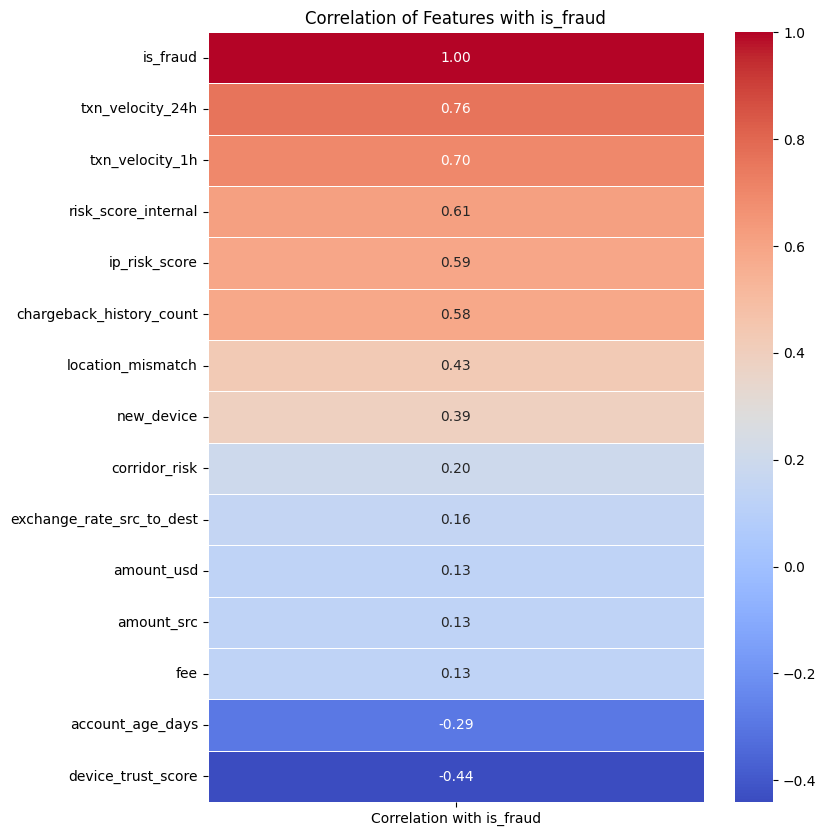

In [ ]:
correlation_series = df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)

# Convert the series to a DataFrame for heatmap plotting
correlation_df = correlation_series.to_frame(name='Correlation with is_fraud')

# Create a heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of Features with is_fraud')
plt.yticks(rotation=0)
plt.show()

## Exploring Variables vs Fraud

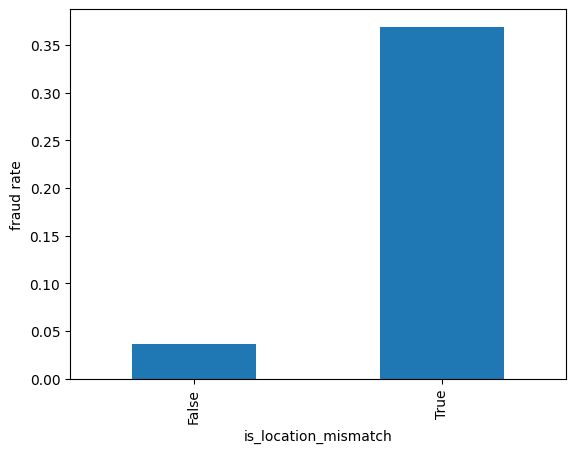

In [ ]:
df.groupby("location_mismatch")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("is_location_mismatch")
plt.show()

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
cat_cols

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'device_id',
       'ip_address', 'ip_country', 'kyc_tier', 'home_country_cleaned'],
      dtype='object')

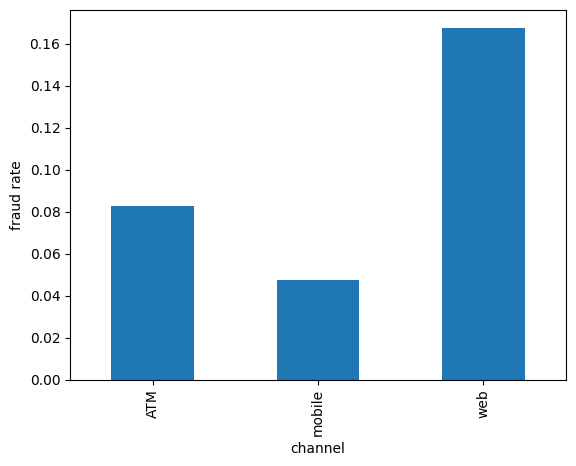

In [ ]:
df.groupby("channel")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("channel")
plt.show()


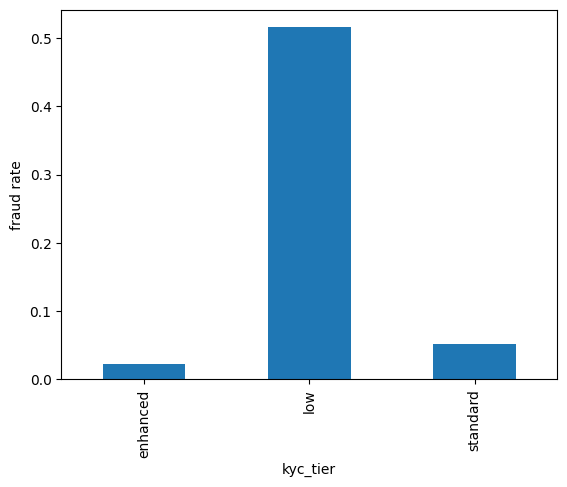

In [ ]:
df.groupby("kyc_tier")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("kyc_tier")
plt.show()

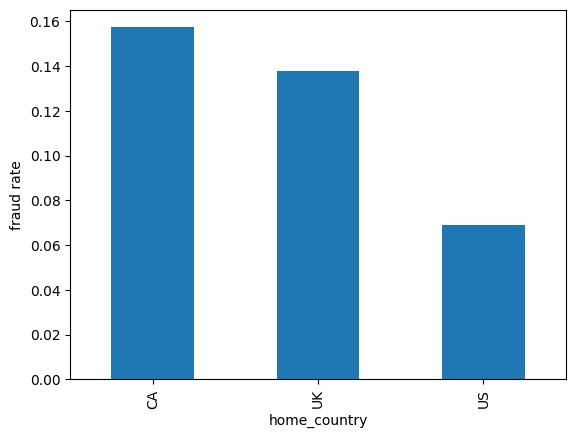

In [ ]:

df.groupby("home_country_cleaned")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("home_country")
plt.show()

## Feature Engineering

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = (df['timestamp'].dt.dayofweek >= 5).astype(int)

In [ ]:
fraud_by_hour = df.groupby('hour')['is_fraud'].mean()
fraud_by_day_of_week = df.groupby('day_of_week')['is_fraud'].mean()
fraud_by_month = df.groupby('month')['is_fraud'].mean()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

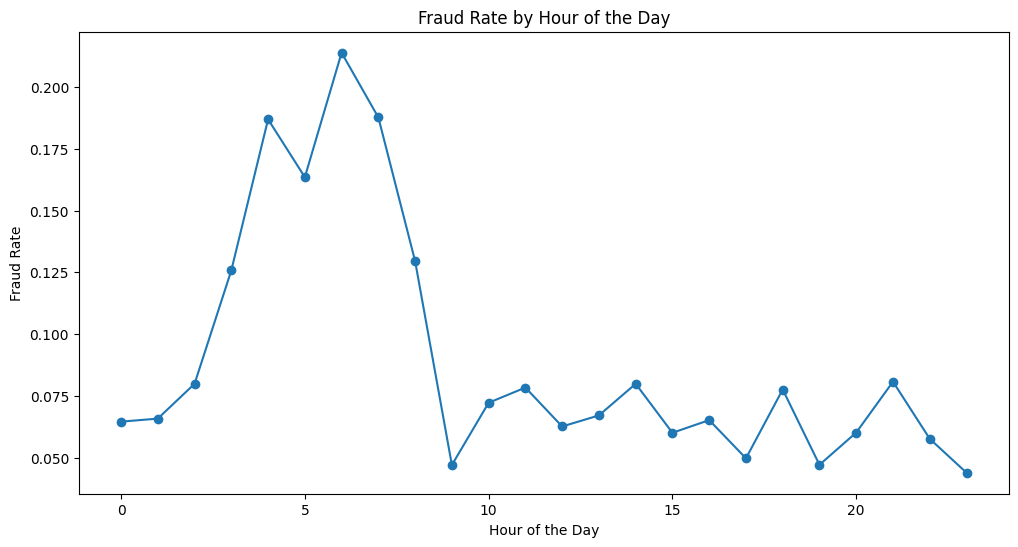

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(fraud_by_hour.index, fraud_by_hour.values, marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')
plt

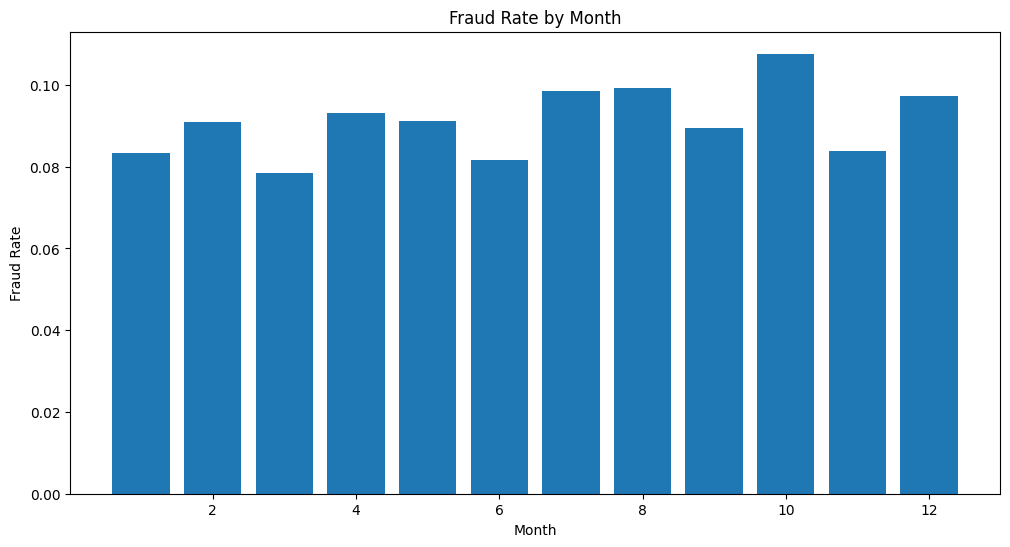

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(fraud_by_month.index, fraud_by_month.values)
plt.xlabel('Month')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Month')
plt.show()

In [ ]:
df['account_age_days'].describe()

,account_age_days
count,10757.000000
mean,393.076508
std,342.046871
min,1.000000
25%,147.000000
50%,281.000000
75%,661.000000
max,1095.000000


In [ ]:
bins = [0, 30, 90, 365, float('inf')]
labels = ['<30 days', '30-90 days', '91-365 days', '>365 days']
df['account_age_bucket'] = pd.cut(df['account_age_days'], bins=bins, labels=labels, right=False)

In [ ]:
fraud_rate_by_bucket = df.groupby('account_age_bucket', observed=False)['is_fraud'].mean().reset_index()
print("Fraud rate by account age bucket calculated successfully.")


Fraud rate by account age bucket calculated successfully.


In [ ]:
overall_fraud_rate = df['is_fraud'].mean()
print(f"Overall fraud rate calculated: {overall_fraud_rate}")

Overall fraud rate calculated: 0.09128939295342568


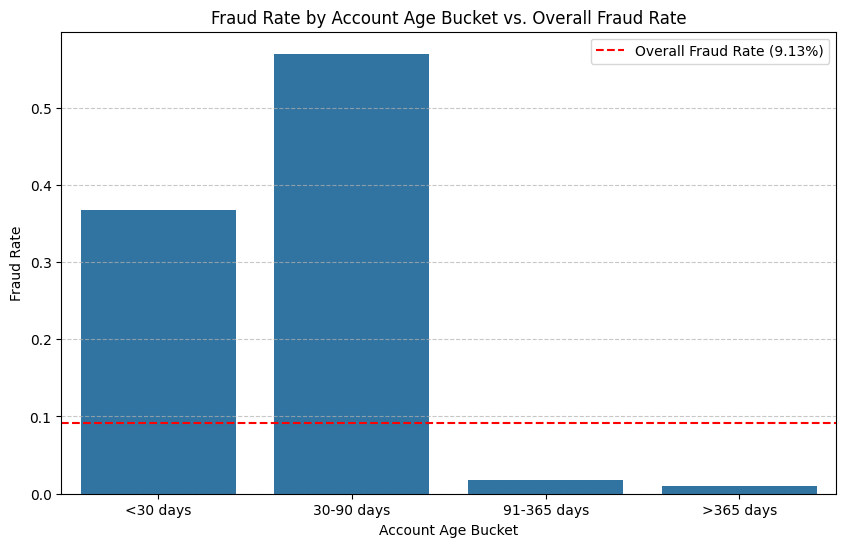

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='account_age_bucket', y='is_fraud', data=fraud_rate_by_bucket)
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.title('Fraud Rate by Account Age Bucket vs. Overall Fraud Rate')
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

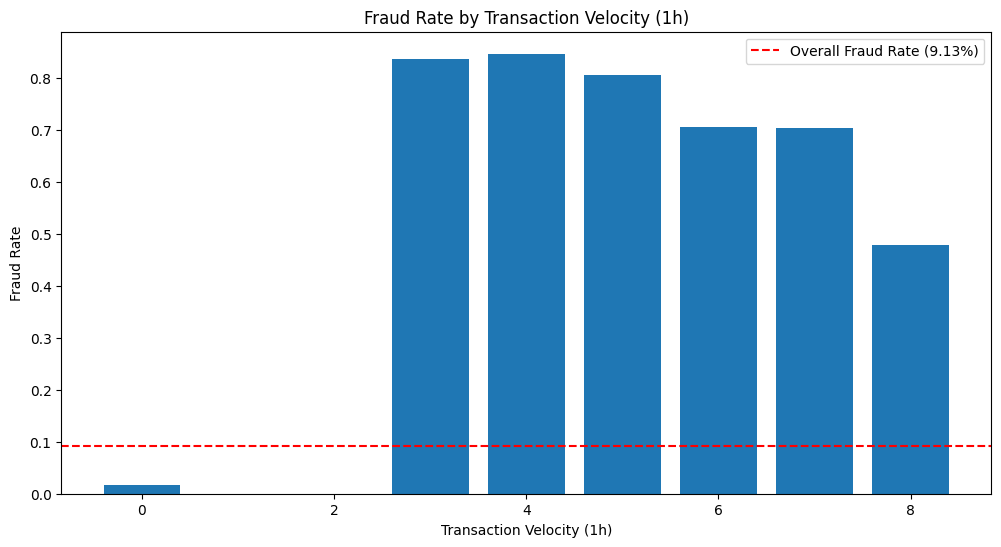

In [ ]:
fraud_by_velocity = df.groupby('txn_velocity_1h')['is_fraud'].mean()

plt.figure(figsize=(12, 6))
plt.bar(fraud_by_velocity.index, fraud_by_velocity.values)
plt.xlabel('Transaction Velocity (1h)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (1h)')
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.legend()
plt.show()

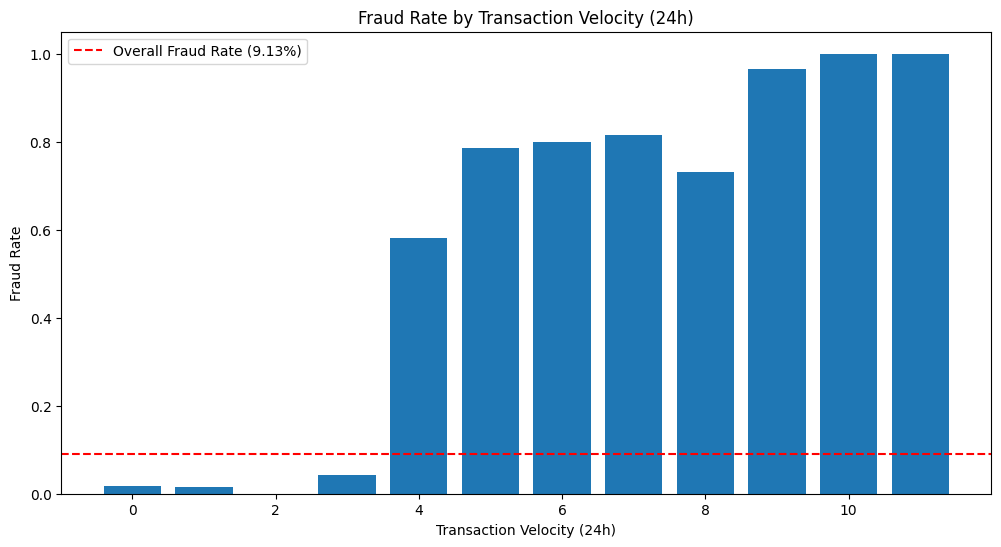

In [ ]:

fraud_by_24velocity = df.groupby('txn_velocity_24h')['is_fraud'].mean()

plt.figure(figsize=(12, 6))
plt.bar(fraud_by_24velocity.index, fraud_by_24velocity.values)
plt.xlabel('Transaction Velocity (24h)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (24h)')
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.legend()
plt.show()


In [ ]:
bins = [0, 100, 500, 1000, 2000, 5000, float('inf')]
labels = ['<100', '100-500', '500-1000', '1000-2000', '2000-5000', '>5000']
df['amount_bucket'] = pd.cut(df['amount_usd'], bins=bins, labels=labels, right=False)

In [ ]:
fraud_rate_by_amount_bucket = df.groupby('amount_bucket', observed=False)['is_fraud'].mean().reset_index()

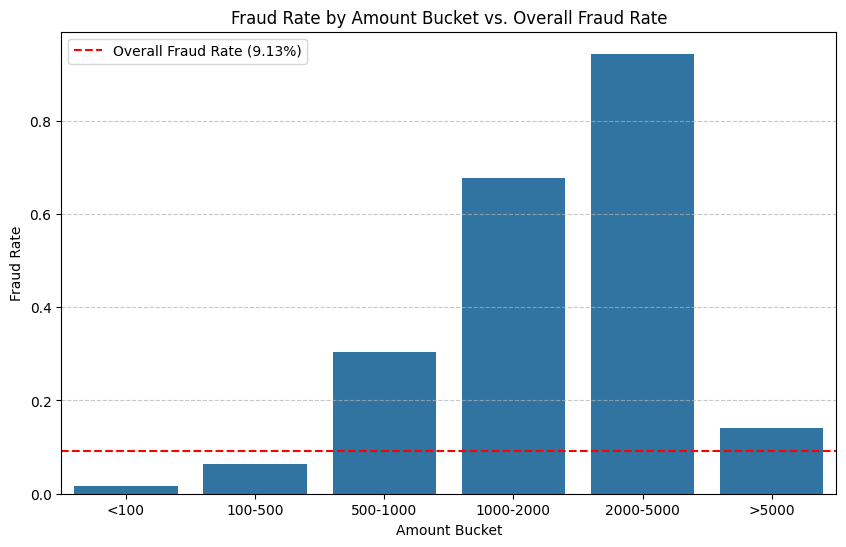

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='amount_bucket', y='is_fraud', data=fraud_rate_by_amount_bucket)
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.title('Fraud Rate by Amount Bucket vs. Overall Fraud Rate')
plt.xlabel('Amount Bucket')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
bins = [0, 0.3, 0.5, 0.7, 0.8, 1.0]
labels = ['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.8', '>0.8']
df['ip_risk_score_bucket'] = pd.cut(df['ip_risk_score'], bins=bins, labels=labels, right=False)

In [ ]:
fraud_rate_by_ip_risk_bucket = df.groupby('ip_risk_score_bucket', observed=False)['is_fraud'].mean().reset_index()

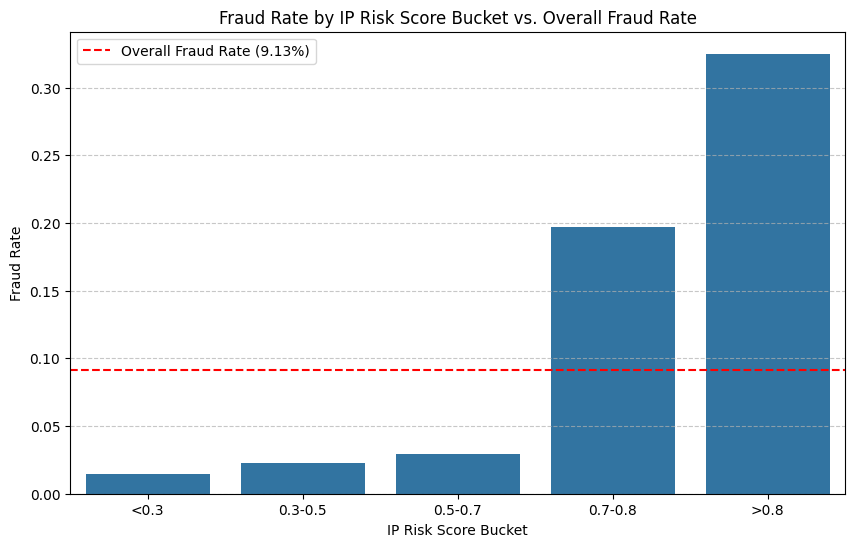

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='ip_risk_score_bucket', y='is_fraud', data=fraud_rate_by_ip_risk_bucket)
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.title('Fraud Rate by IP Risk Score Bucket vs. Overall Fraud Rate')
plt.xlabel('IP Risk Score Bucket')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
bins = [0, 0.3, 0.5, 0.7, 0.8, 1.0]
labels = ['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.8', '>0.8']
df['device_trust_score_bucket'] = pd.cut(df['device_trust_score'], bins=bins, labels=labels, right=False)

In [ ]:
fraud_rate_by_device_trust_bucket = df.groupby('device_trust_score_bucket', observed=False)['is_fraud'].mean().reset_index()

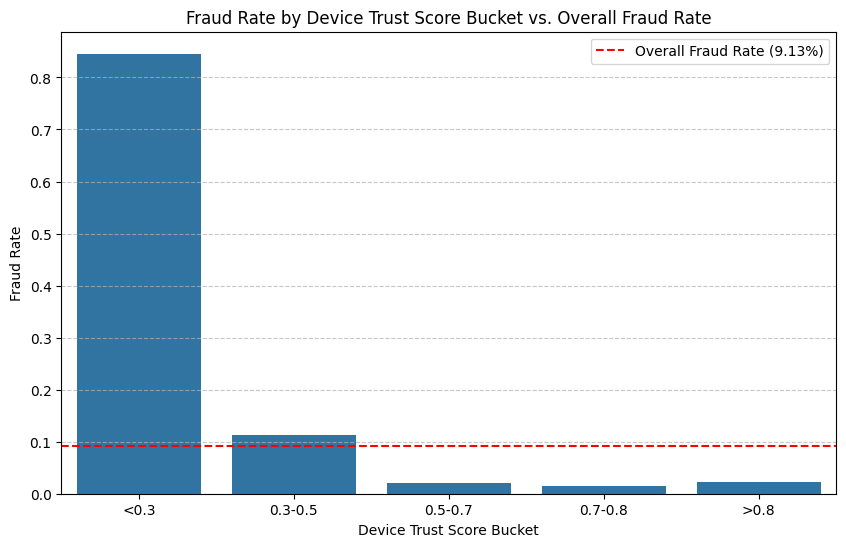

In [ ]:

plt.figure(figsize=(10, 6))
sns.barplot(x='device_trust_score_bucket', y='is_fraud', data=fraud_rate_by_device_trust_bucket)
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.title('Fraud Rate by Device Trust Score Bucket vs. Overall Fraud Rate')
plt.xlabel('Device Trust Score Bucket')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Engineered Variables

In [ ]:
df['night_hours'] = ((df['hour'] >= 3) & (df['hour'] <= 7)).astype(int)

In [ ]:
bins = [0, 30, 90, float('inf')]
labels = ['very new', 'relatively new', 'matured']
df['account_age_breakdown'] = pd.cut(df['account_age_days'], bins=bins, labels=labels, right=False)
print("Created 'account_age_breakdown' column successfully.")

Created 'account_age_breakdown' column successfully.


In [ ]:

bins = [0, 500, 2000, 5000, float('inf')]
labels = ['low', 'mid', 'high', 'very high']
df['amount_breakdown'] = pd.cut(df['amount_usd'], bins=bins, labels=labels, right=False)
print("Created 'amount_breakdown' column successfully.")

Created 'amount_breakdown' column successfully.


In [ ]:
bins = [0, 0.3, 0.6, float('inf')]
labels = ['low', 'medium', 'high']
df['ip_risk'] = pd.cut(df['ip_risk_score'], bins=bins, labels=labels, right=False)
print("Created 'ip_risk' column successfully.")

Created 'ip_risk' column successfully.


In [ ]:
bins = [0, 0.3, 0.6, float('inf')]
labels = ['low', 'medium', 'high']
df['device_risk'] = pd.cut(df['device_trust_score'], bins=bins, labels=labels, right=False)
print("Created 'device_risk' column successfully.")

Created 'device_risk' column successfully.


## Writing New Variables to CSV

In [ ]:
df.to_csv('engineered_features.csv', index=False)
print("DataFrame with engineered features saved to 'engineered_features.csv'.")

DataFrame with engineered features saved to 'engineered_features.csv'.


# Base Line Models

## Importing Engineered Features

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('engineered_features.csv')
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,is_weekend,account_age_bucket,amount_bucket,ip_risk_score_bucket,device_trust_score_bucket,night_hours,account_age_breakdown,amount_breakdown,ip_risk,device_risk
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0,91-365 days,100-500,<0.3,0.5-0.7,0,matured,low,low,medium
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0,>365 days,100-500,0.5-0.7,0.3-0.5,0,matured,low,medium,medium
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0,>365 days,100-500,0.3-0.5,>0.8,0,matured,low,medium,high
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0,91-365 days,<100,0.5-0.7,0.5-0.7,0,matured,low,medium,medium
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0,91-365 days,100-500,<0.3,>0.8,0,matured,low,low,high


In [ ]:
df.isna().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


In [ ]:
print(df['timestamp'].dtype)

object


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

## More Engineered Features

In [ ]:
df['is_high_velocity_1h'] = (df['txn_velocity_1h'] < 4).astype(int)

In [ ]:
df['is_high_velocity_24h'] = (df['txn_velocity_24h'] < 4).astype(int)

## Creating Train and Test Dataset

In [ ]:
print(df['timestamp'].dtype)

datetime64[ns, UTC]


In [ ]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'home_country_cleaned',
       'hour', 'day_of_week', 'month', 'is_weekend', 'account_age_bucket',
       'amount_bucket', 'ip_risk_score_bucket', 'device_trust_score_bucket',
       'night_hours', 'account_age_breakdown', 'amount_breakdown', 'ip_risk',
       'device_risk', 'is_high_velocity_1h', 'is_high_velocity_24h'],
      dtype='object')

In [ ]:
df = df.sort_values(by='timestamp').reset_index(drop=True)

In [ ]:
columns_to_drop = ['transaction_id',
                   'timestamp',
                   'customer_id',
                   'exchange_rate_src_to_dest',
                   'device_id',
                   'ip_risk_score',
                   'txn_velocity_1h',
                   'txn_velocity_24h',
                   'account_age_days',
                   ]
df.drop(columns=columns_to_drop, inplace=True)

In [ ]:
all_features = df.columns.tolist()
all_features.remove('is_fraud')
all_features

['home_country',
 'source_currency',
 'dest_currency',
 'channel',
 'amount_src',
 'amount_usd',
 'fee',
 'new_device',
 'ip_address',
 'ip_country',
 'location_mismatch',
 'kyc_tier',
 'device_trust_score',
 'chargeback_history_count',
 'risk_score_internal',
 'corridor_risk',
 'home_country_cleaned',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'account_age_bucket',
 'amount_bucket',
 'ip_risk_score_bucket',
 'device_trust_score_bucket',
 'night_hours',
 'account_age_breakdown',
 'amount_breakdown',
 'ip_risk',
 'device_risk',
 'is_high_velocity_1h',
 'is_high_velocity_24h']

In [ ]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df)} rows {(train_df['is_fraud']).sum()} fraud, {(train_df['is_fraud']).mean():.3f} rate of fraud")
print(f"Test: {len(test_df)} rows {(test_df['is_fraud']).sum()} fraud, {(test_df['is_fraud']).mean():.3f} rate of fraud")

Train: 8605 rows 675 fraud, 0.078 rate of fraud
Test: 2152 rows 307 fraud, 0.143 rate of fraud


In [ ]:
X_train = train_df[all_features]
y_train = train_df['is_fraud']

X_test = test_df[all_features]
y_test = test_df['is_fraud']

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (8605, 32), y_train: (8605,)
X_test: (2152, 32), y_test: (2152,)


## Hot Encoding and Standard Scaling

In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
numerical_features.remove('is_fraud')

In [ ]:
len(categorical_features) + len(numerical_features)

30

In [ ]:
remaining_features = list(
    set(all_features) - set(categorical_features) - set(numerical_features)
)
remaining_features

['location_mismatch', 'new_device']

In [ ]:
print(df['location_mismatch'].dtype)

bool


In [ ]:
boolean_features = ['location_mismatch', 'new_device']

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('bool', 'passthrough', boolean_features)
    ])


X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"Original features: {len(all_features)}, After encoding: {X_train_preprocessed.shape[1]}")


X_train_preprocessed: (8605, 8523)
Original features: 32, After encoding: 8523


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
df.isna().sum()

,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0
new_device,0
ip_address,0
ip_country,0


## Training Baseline Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_preprocessed, y_train)

y_pred_lr = lr_model.predict(X_test_preprocessed)
y_proba_lr = lr_model.predict_proba(X_test_preprocessed)[:, 1]

print("Logistic Regression Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_lr):.2f}")

Logistic Regression Results:

Confusion Matrix:
[[1835   10]
 [  19  288]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.97      0.94      0.95       307

    accuracy                           0.99      2152
   macro avg       0.98      0.97      0.97      2152
weighted avg       0.99      0.99      0.99      2152


ROC AUC Score:, 0.98


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.25, 0.4, 0.6, 0.65, 0.8]



In [ ]:
for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    print(f"Threshold: {t}")
    print(
        classification_report(y_test, y_pred_t)
    )

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      1845
           1       0.38      0.98      0.55       307

    accuracy                           0.77      2152
   macro avg       0.69      0.86      0.70      2152
weighted avg       0.91      0.77      0.81      2152

Threshold: 0.25
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1845
           1       0.70      0.95      0.80       307

    accuracy                           0.93      2152
   macro avg       0.84      0.94      0.88      2152
weighted avg       0.95      0.93      0.94      2152

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1845
           1       0.90      0.94      0.92       307

    accuracy                           0.98      2152
   macro avg       0.94      0.96      0.95      2152
weighted avg       0.98     

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    max_depth=10,
    class_weight='balanced',
    n_estimators=100,
    random_state=42,
    n_jobs=1
    )
rf_model.fit(X_train_preprocessed, y_train)

#Predict on test
y_pred_rf = rf_model.predict(X_test_preprocessed)
y_proba_rf = rf_model.predict_proba(X_test_preprocessed)[:, 1]

#Evaluation
print("Random Forest Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_rf):.2f}")

Random Forest Results:

Confusion Matrix:
[[1844    1]
 [  24  283]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       1.00      0.92      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.98      2152
weighted avg       0.99      0.99      0.99      2152


ROC AUC Score:, 0.98


In [ ]:
for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    print(f"Threshold: {t}")
    print(
        classification_report(y_test, y_pred_t)
    )

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1845
           1       0.14      1.00      0.25       307

    accuracy                           0.14      2152
   macro avg       0.07      0.50      0.12      2152
weighted avg       0.02      0.14      0.04      2152

Threshold: 0.25
              precision    recall  f1-score   support

           0       1.00      0.59      0.74      1845
           1       0.29      0.99      0.44       307

    accuracy                           0.65      2152
   macro avg       0.64      0.79      0.59      2152
weighted avg       0.89      0.65      0.70      2152

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1845
           1       0.81      0.95      0.87       307

    accuracy                           0.96      2152
   macro avg       0.90      0.96      0.93      2152
weighted avg       0.97     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from xgboost import XGBClassifier

scale_pos_w = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_w,
    random_state=42,
    eval_metric='logloss'
    )

xgb_model.fit(X_train_preprocessed, y_train)

#Predict at test
y_pred_xgb = xgb_model.predict(X_test_preprocessed)
y_proba_xgb = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

#Evaluation
print("XGBoost Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_xgb):.2f}")

XGBoost Results:

Confusion Matrix:
[[1823   22]
 [  22  285]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.93      0.93      0.93       307

    accuracy                           0.98      2152
   macro avg       0.96      0.96      0.96      2152
weighted avg       0.98      0.98      0.98      2152


ROC AUC Score:, 0.97


In [ ]:
for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    print(f"Threshold: {t}")
    print(
        classification_report(y_test, y_pred_t)
    )

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.75      0.86      1845
           1       0.39      0.96      0.56       307

    accuracy                           0.78      2152
   macro avg       0.69      0.86      0.71      2152
weighted avg       0.91      0.78      0.81      2152

Threshold: 0.25
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1845
           1       0.69      0.94      0.80       307

    accuracy                           0.93      2152
   macro avg       0.84      0.94      0.88      2152
weighted avg       0.95      0.93      0.94      2152

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1845
           1       0.84      0.93      0.88       307

    accuracy                           0.97      2152
   macro avg       0.92      0.95      0.93      2152
weighted avg       0.97     

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    verbosity=-1,
    random_state=42,
    )

lgbm_model.fit(X_train_preprocessed, y_train)

#Predict as test
y_pred_lgbm = lgbm_model.predict(X_test_preprocessed)
y_proba_lgbm = lgbm_model.predict_proba(X_test_preprocessed)[:, 1]

#Evaluation
print("LightGBM Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))
print(f"\nROC AUC Score:, {roc_auc_score(y_test, y_proba_lgbm):.2f}")

LightGBM Results:

Confusion Matrix:
[[1825   20]
 [  23  284]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.93      0.93      0.93       307

    accuracy                           0.98      2152
   macro avg       0.96      0.96      0.96      2152
weighted avg       0.98      0.98      0.98      2152


ROC AUC Score:, 0.97


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
for t in thresholds:
    y_pred_t = (y_proba_lgbm >= t).astype(int)
    print(
        f"Threshold {t:.2f} | "
        f"Precision: {precision_score(y_test, y_pred_t):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_t):.3f} | "
        f"F1: {f1_score(y_test, y_pred_t):.3f}"
    )

Threshold 0.10 | Precision: 0.462 | Recall: 0.948 | F1: 0.621
Threshold 0.25 | Precision: 0.731 | Recall: 0.938 | F1: 0.822
Threshold 0.40 | Precision: 0.877 | Recall: 0.928 | F1: 0.902
Threshold 0.60 | Precision: 0.969 | Recall: 0.922 | F1: 0.945
Threshold 0.65 | Precision: 0.976 | Recall: 0.919 | F1: 0.946
Threshold 0.80 | Precision: 0.993 | Recall: 0.919 | F1: 0.954


## Feature Importance and SHAP Interpretability

### Logistic Feature Importance

In [ ]:
lr_coeffecients = lr_model.coef_[0]
lr_coeffecients

array([-0.29927674,  0.07749727,  0.44804281, ..., -0.22120174,
        0.89807966, -0.67163988])

In [ ]:
print(len(lr_coeffecients))
print(len(all_features))


8523
32


In [ ]:
cat_encoder = preprocessor.named_transformers_['cat']

cat_features = list(
    cat_encoder.get_feature_names_out(categorical_features)
)


In [ ]:
encoded_features = numerical_features + cat_features + boolean_features
len(encoded_features)

8523

In [ ]:
feature_importance = pd.DataFrame({
    'features': encoded_features,
    'coefficient': lr_coeffecients
})

In [ ]:
feature_importance['abs_coef'] = feature_importance['coefficient'].abs()


In [ ]:
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

In [ ]:
feature_importance.head(15)


,features,coefficient,abs_coef
2976,ip_address_179.17.146.251,3.973414,3.973414
7191,ip_address_62.123.91.131,3.531098,3.531098
4740,ip_address_224.224.80.254,3.482449,3.482449
2569,ip_address_168.175.194.23,3.455229,3.455229
6647,ip_address_48.38.194.193,3.448104,3.448104
958,ip_address_124.240.98.190,3.429779,3.429779
849,ip_address_121.186.93.199,3.319496,3.319496
1233,ip_address_131.60.43.161,3.309542,3.309542
1444,ip_address_137.172.155.222,3.253412,3.253412
5191,ip_address_236.181.218.56,3.209922,3.209922


In [ ]:
def get_original_feature(col):
    if col in numerical_features or col in boolean_features:
        return col

    for orig in categorical_features:
        if col.startswith(orig + '_'):
            return orig
    return col


In [ ]:
feature_importance['original_feature'] = (
    feature_importance['features']
    .apply(get_original_feature)
)


In [ ]:
aggregated_importance = (
    feature_importance
    .groupby('original_feature')['abs_coef']
    .sum()
    .reset_index()
    .sort_values(by='abs_coef', ascending=False)
)


In [ ]:
aggregated_importance

,original_feature,abs_coef
17,ip_address,697.394478
20,ip_risk_score_bucket,3.879158
18,ip_country,3.587003
15,home_country,3.002261
1,account_age_bucket,2.754067
10,dest_currency,2.702696
24,kyc_tier,2.603011
13,device_trust_score_bucket,2.174705
3,amount_bucket,1.527871
0,account_age_breakdown,1.253230


### Random Forest Feature Importance

In [ ]:
rf_importances = rf_model.feature_importances_


In [ ]:
len(rf_importances) == X_train_preprocessed.shape[1]


True

In [ ]:
rf_feature_importance = pd.DataFrame({
    'feature': encoded_features,
    'importance': rf_importances
})

In [ ]:
rf_feature_importance = rf_feature_importance.sort_values(
    by='importance',
    ascending=False
)

rf_feature_importance.head(15)


,feature,importance
8510,device_trust_score_bucket_<0.3,0.073202
13,is_high_velocity_24h,0.064732
5,risk_score_internal,0.063630
3,device_trust_score,0.051537
4,chargeback_history_count,0.042385
12,is_high_velocity_1h,0.040601
8521,location_mismatch,0.039748
8507,ip_risk_score_bucket_nan,0.034499
8519,device_risk_low,0.034443
8491,kyc_tier_low,0.032451


In [ ]:
rf_feature_importance['original_feature'] = (
    rf_feature_importance['feature']
    .apply(get_original_feature)
)


In [ ]:
rf_aggregated_importance = (
    rf_feature_importance
    .groupby('original_feature')['importance']
    .sum()
    .reset_index()
    .sort_values(by='importance', ascending=False)
)


In [ ]:
rf_aggregated_importance.head(10)


,original_feature,importance
13,device_trust_score_bucket,0.101143
20,ip_risk_score_bucket,0.071978
22,is_high_velocity_24h,0.064732
29,risk_score_internal,0.063630
1,account_age_bucket,0.059619
24,kyc_tier,0.055143
17,ip_address,0.052281
12,device_trust_score,0.051537
7,chargeback_history_count,0.042385
21,is_high_velocity_1h,0.040601


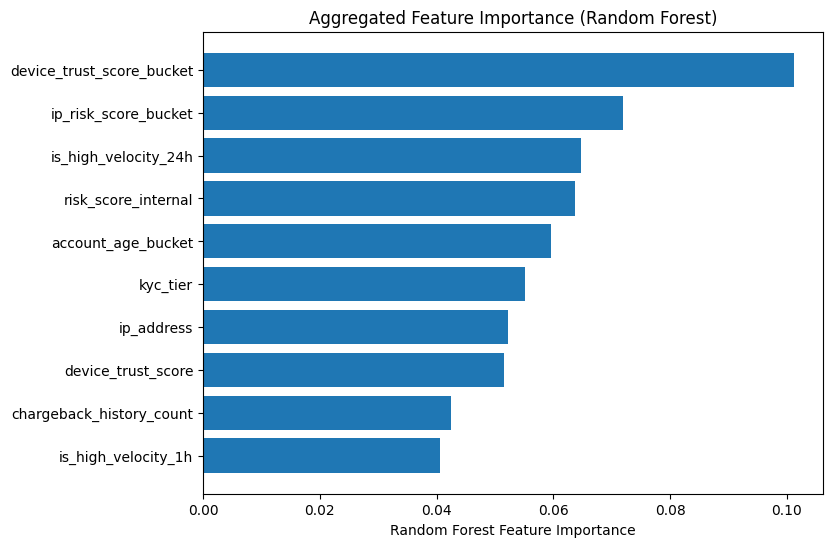

In [ ]:
import matplotlib.pyplot as plt

top_rf = rf_aggregated_importance.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_rf['original_feature'], top_rf['importance'])
plt.xlabel('Random Forest Feature Importance')
plt.title('Aggregated Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.show()


### XGBoost Feature Importance

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)


In [ ]:
shap_values = explainer.shap_values(X_test_preprocessed)


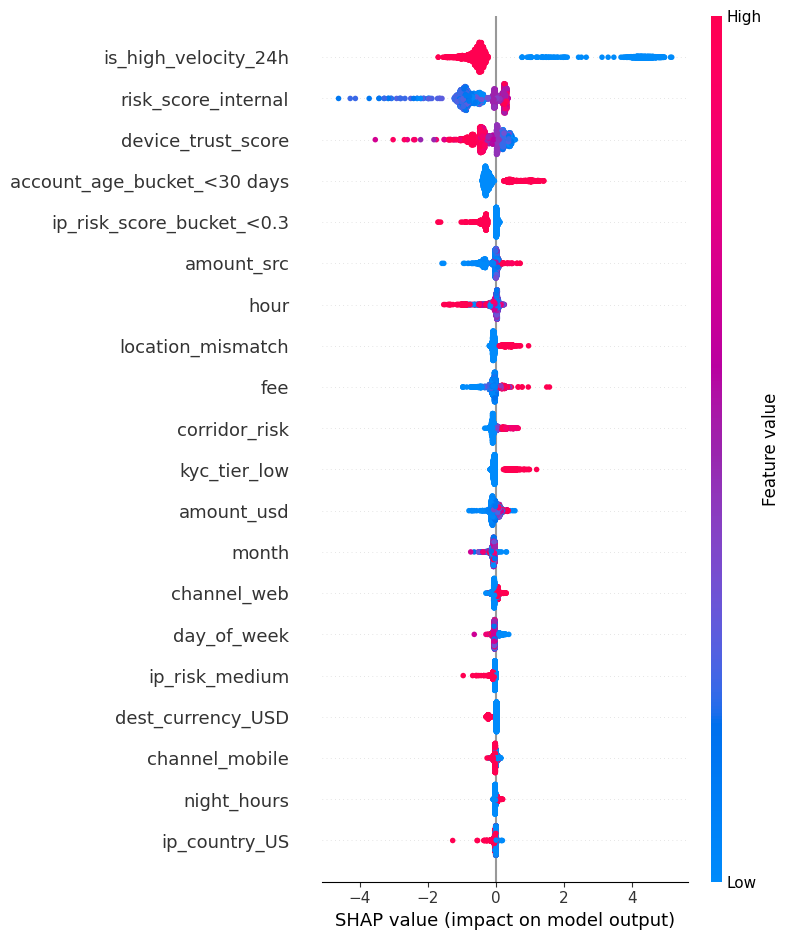

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=encoded_features
)


# Advanced Modeling & Imbalance Handling

## Tuning XGBoost and LightGBM Models

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'scale_pos_weight': [scale_pos_w * 0.25, scale_pos_w * 0.5, scale_pos_w, scale_pos_w * 2]

}

xgb_tuned = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    scoring='average_precision',
    n_iter=25,
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train_preprocessed, y_train)

print("Best Parameters:", xgb_tuned.best_params_)
print("Best Score:", xgb_tuned.best_score_)

Best Parameters: {'subsample': 0.8, 'scale_pos_weight': np.float64(23.496296296296297), 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best Score: 0.8500263074584301


In [ ]:
results_df = pd.DataFrame(xgb_tuned.cv_results_)
results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_scale_pos_weight,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,48.585271,0.857440,0.153665,0.007431,1.0,11.748148,200,10,6,0.20,0.8,"{'subsample': 1.0, 'scale_pos_weight': 11.7481...",0.681173,0.913795,0.907919,0.834296,0.108301,21
1,64.569369,2.043353,0.174440,0.002718,0.9,23.496296,200,10,10,0.01,0.9,"{'subsample': 0.9, 'scale_pos_weight': 23.4962...",0.686820,0.918301,0.907985,0.837702,0.106773,13
2,23.631901,1.651537,0.152295,0.008299,1.0,2.937037,100,5,6,0.01,0.9,"{'subsample': 1.0, 'scale_pos_weight': 2.93703...",0.690551,0.924621,0.911013,0.842062,0.107278,5
3,22.730025,1.718285,0.147093,0.002298,0.8,5.874074,100,1,6,0.01,0.9,"{'subsample': 0.8, 'scale_pos_weight': 5.87407...",0.682548,0.928155,0.912084,0.840929,0.112184,6
4,19.657825,0.299276,0.209137,0.077248,0.8,11.748148,100,1,3,0.20,0.9,"{'subsample': 0.8, 'scale_pos_weight': 11.7481...",0.687656,0.913248,0.909321,0.836742,0.105432,16


In [ ]:
params_df = results_df['params'].apply(pd.Series)

log_df = pd.concat(
    [
        params_df,
        results_df[
            ['mean_test_score', 'std_test_score', 'rank_test_score']
        ]
    ],
    axis=1
)


In [ ]:
log_df = log_df.rename(columns={
    'mean_test_score': 'cv_roc_auc_mean',
    'std_test_score': 'cv_roc_auc_std',
    'rank_test_score': 'cv_rank'
})


In [ ]:
log_df = log_df.sort_values('cv_rank')


In [ ]:
log_df.to_csv("xgb_hyperparameter_tuning_log.csv", index=False)


In [ ]:
param_dist_lgbm = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.5, 0.8, 1.0],
    'feature_fraction': [0.8, 1.0],

    'scale_pos_weight': [scale_pos_w * 0.25, scale_pos_w * 0.5, scale_pos_w, scale_pos_w * 2]

}

In [ ]:
print([scale_pos_w * 0.25, scale_pos_w * 0.5, scale_pos_w, scale_pos_w * 2])

[np.float64(2.937037037037037), np.float64(5.874074074074074), np.float64(11.748148148148148), np.float64(23.496296296296297)]


In [ ]:
lgbm_tuned = RandomizedSearchCV(
    estimator=lgbm_model,
    scoring='average_precision',
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
)

lgbm_tuned.fit(X_train_preprocessed, y_train)

RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(class_weight='balanced',
                                            max_depth=6, random_state=42,
                                            verbosity=-1),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 6, 10],
                                        'min_child_weight': [1, 5, 10],
                                        'n_estimators': [50, 100, 200],
                                        'scale_pos_weight': [np.float64(2.937037037037037),
                                                             np.float64(5.874074074074074),
                                                             np.float64(11.748148148148148),
                                                             np.float64(23.496296296296297)],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='average_precision')

In [ ]:
tuned_xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_w * 2,
    random_state=42,
    eval_metric='logloss'
    )

tuned_xgb_model.fit(X_train_preprocessed, y_train)
y_proba_tuned_xgb_model = tuned_xgb_model.predict_proba(X_test_preprocessed)[:, 1]




In [ ]:
threshold = 0.7
y_pred_t = (y_proba_tuned_xgb_model >= threshold).astype(int)
print(classification_report(y_test, y_pred_t))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.93      0.95       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152



In [ ]:
tuned_lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.2,
    class_weight='balanced',
    verbosity=-1,
    random_state=42,
    colsample_bytree=0.8,
    min_child_weight=10,
    scale_pos_weight=scale_pos_w
    )

tuned_lgbm_model.fit(X_train_preprocessed, y_train)
y_proba_tuned_lgbm_model = tuned_lgbm_model.predict_proba(X_test_preprocessed)[:, 1]



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
y_pred_t = (y_proba_tuned_lgbm_model >= threshold).astype(int)
print(classification_report(y_test, y_pred_t))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.93      0.93      0.93       307

    accuracy                           0.98      2152
   macro avg       0.96      0.96      0.96      2152
weighted avg       0.98      0.98      0.98      2152



## Further Experimentation

### SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

sampling_grid = [0.1, 0.2, 0.3, 0.5]
smote_results = []


In [ ]:
for ratio in sampling_grid:
    smote = SMOTE(
        sampling_strategy=ratio,
        k_neighbors=5,
        random_state=42
    )

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train_preprocessed,
        y_train
    )

    xgb_model = XGBClassifier(
      n_estimators=100,
      max_depth=3,
      learning_rate=0.01,
      min_child_weight=1,
      subsample=0.8,
      colsample_bytree=0.8,
      scale_pos_weight=scale_pos_w * 2,
      random_state=42,
      eval_metric='logloss'
      )

    # xgb_model = XGBClassifier(
    #     n_estimators=100,
    #     max_depth=6,
    #     learning_rate=0.1,
    #     scale_pos_weight=scale_pos_w,
    #     random_state=42,
    #     eval_metric='logloss'
    #     )

    xgb_model.fit(X_train_smote, y_train_smote)

    y_proba_smote_xgb_model = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

    y_pred_t = (y_proba_smote_xgb_model >= threshold).astype(int)

    smote_results.append({
        'sampling_ratio': ratio,
        'classification_report': classification_report(y_test, y_pred_t)
    })

In [ ]:
for result in smote_results:
    print(f"Sampling Ratio: {result['sampling_ratio']}")
    print(result['classification_report'])
    print("-" * 50)

Sampling Ratio: 0.1
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.98      0.93      0.95       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.2
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1845
           1       0.64      0.95      0.77       307

    accuracy                           0.92      2152
   macro avg       0.82      0.93      0.86      2152
weighted avg       0.94      0.92      0.92      2152

--------------------------------------------------
Sampling Ratio: 0.3
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1845
           1       0.59      0.96      0.73       307

    accuracy        

In [ ]:
smote = SMOTE(
        sampling_strategy=0.1,
        k_neighbors=5,
        random_state=42
    )

X_train_smote, y_train_smote = smote.fit_resample(
  X_train_preprocessed,
  y_train
)

smote_xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_w,
    random_state=42,
    eval_metric='logloss'
    )

smote_xgb_model.fit(X_train_smote, y_train_smote)
y_proba_smote_xgb_model = smote_xgb_model.predict_proba(X_test_preprocessed)[:, 1]

In [ ]:
y_pred_t = (y_proba_smote_xgb_model >= threshold).astype(int)
print(classification_report(y_test, y_pred_t))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.93      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.98      2152
weighted avg       0.99      0.99      0.99      2152



In [ ]:
smote_lgbm_results = []

for ratio in sampling_grid:
    smote = SMOTE(
        sampling_strategy=ratio,
        k_neighbors=5,
        random_state=42
    )

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train_preprocessed,
        y_train
    )

    lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    verbosity=-1,
    random_state=42,
    )

    lgbm_model.fit(X_train_smote, y_train_smote)

    y_proba_smote_lgbm_model = lgbm_model.predict_proba(X_test_preprocessed)[:, 1]

    y_pred_t = (y_proba_smote_lgbm_model >= threshold).astype(int)

    smote_lgbm_results.append({
        'sampling_ratio': ratio,
        'classification_report': classification_report(y_test, y_pred_t)
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
for result in smote_lgbm_results:
    print(f"Sampling Ratio: {result['sampling_ratio']}")
    print(result['classification_report'])
    print("-" * 50)

Sampling Ratio: 0.1
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.92      0.95       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.2
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       1.00      0.92      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.98      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.3
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       1.00      0.93      0.96       307

    accuracy        

In [ ]:
smote = SMOTE(
        sampling_strategy=0.5,
        k_neighbors=5,
        random_state=42
    )

X_train_smote, y_train_smote = smote.fit_resample(
  X_train_preprocessed,
  y_train
)

smote_lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_w,
    random_state=42,
    eval_metric='logloss'
    )

smote_lgbm_model.fit(X_train_smote, y_train_smote)
y_proba_smote_lgbm_model = smote_lgbm_model.predict_proba(X_test_preprocessed)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
y_pred_t = (y_proba_smote_lgbm_model >= threshold).astype(int)
print(classification_report(y_test, y_pred_t))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.97      0.93      0.95       307

    accuracy                           0.99      2152
   macro avg       0.98      0.96      0.97      2152
weighted avg       0.99      0.99      0.98      2152



### Under-sampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

xgb_under_sampling_results = []

for ratio in sampling_grid:
    rus = RandomUnderSampler(
        sampling_strategy=ratio,
        random_state=42
    )

    X_under, y_under = rus.fit_resample(
        X_train_preprocessed,
        y_train
    )

    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_w,
        random_state=42,
        eval_metric='logloss'
        )

    xgb_model.fit(X_under, y_under)
    xgb_model.fit(X_under, y_under)

    y_prob = xgb_model.predict_proba(X_test_preprocessed)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    xgb_under_sampling_results.append({
        'sampling_ratio': ratio,
        'classification_report': classification_report(y_test, y_pred)
    })

In [ ]:
for result in xgb_under_sampling_results:
    print(f"Sampling Ratio: {result['sampling_ratio']}")
    print(result['classification_report'])
    print("-" * 50)

Sampling Ratio: 0.1
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.98      0.93      0.95       307

    accuracy                           0.99      2152
   macro avg       0.98      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.2
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1845
           1       0.89      0.93      0.91       307

    accuracy                           0.97      2152
   macro avg       0.94      0.95      0.95      2152
weighted avg       0.97      0.97      0.97      2152

--------------------------------------------------
Sampling Ratio: 0.3
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1845
           1       0.85      0.93      0.89       307

    accuracy        

In [ ]:
lgbm_under_sampling_results = []

for ratio in sampling_grid:
    rus = RandomUnderSampler(
        sampling_strategy=ratio,
        random_state=42
    )

    X_under, y_under = rus.fit_resample(
        X_train_preprocessed,
        y_train
    )

    lgbm_model = LGBMClassifier(
      n_estimators=100,
      max_depth=6,
      learning_rate=0.1,
      class_weight='balanced',
      verbosity=-1,
      random_state=42,
      )

    lgbm_model.fit(X_under, y_under)
    lgbm_model.fit(X_under, y_under)

    y_prob = lgbm_model.predict_proba(X_test_preprocessed)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    lgbm_under_sampling_results.append({
        'sampling_ratio': ratio,
        'classification_report': classification_report(y_test, y_pred)
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
for result in lgbm_under_sampling_results:
    print(f"Sampling Ratio: {result['sampling_ratio']}")
    print(result['classification_report'])
    print("-" * 50)

Sampling Ratio: 0.1
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.92      0.96       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.2
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1845
           1       0.99      0.92      0.95       307

    accuracy                           0.99      2152
   macro avg       0.99      0.96      0.97      2152
weighted avg       0.99      0.99      0.99      2152

--------------------------------------------------
Sampling Ratio: 0.3
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1845
           1       0.95      0.93      0.94       307

    accuracy        

# Experiment Logs

## SMOTE Logs

### SMOTE & Undersampling Experiments — XGBoost (k=5, threshold=0.7) | LGBM (threshold=0.7)



| Model | Sampling Strategy | Sampling Ratio | Precision (Fraud) | Recall (Fraud) | F1 (Fraud) | Accuracy | Decision | Notes | |
|------|------------------|----------------|-------------------|----------------|------------|----------|-----|----------|------|
| XGB | SMOTE | 0.1 | 0.98 | 0.93 | 0.95 | 0.99 | Keep (Exploratory) | Best SMOTE trade-off |
| XGB | SMOTE | 0.2 | 0.66 | 0.95 | 0.78 | 0.92 |  Reject | Precision collapse |
| XGB | SMOTE | 0.3 | 0.61 | 0.96 | 0.74 | 0.91 |  Reject | Excess false positives |
| XGB | SMOTE | 0.5 | 0.38 | 0.97 | 0.54 | 0.77 |  Reject | Severe degradation |
| LGBM | SMOTE | 0.1 | 0.99 | 0.92 | 0.95 | 0.99 |  Keep (Exploratory) | Stable but no recall gain |
| LGBM | SMOTE | 0.2 | 1.00 | 0.92 | 0.96 | 0.99 |  Reject | No improvement over 0.1 |
| LGBM | SMOTE | 0.3 | 1.00 | 0.92 | 0.96 | 0.99 |  Reject | Performance plateau |
| LGBM | SMOTE | 0.5 | 1.00 | 0.92 | 0.96 | 0.99 |  Reject | Overconfidence risk |
| XGB | Undersampling | 0.1 | 0.96 | 0.92 | 0.94 | 0.98 |  Keep (Exploratory) | Least harmful undersampling |
| XGB | Undersampling | 0.2 | 0.83 | 0.93 | 0.88 | 0.96 |  Reject | Precision drops |
| XGB | Undersampling | 0.3 | 0.74 | 0.94 | 0.83 | 0.94 |  Reject | Majority signal loss |
| XGB | Undersampling | 0.5 | 0.65 | 0.94 | 0.77 | 0.92 |  Reject | Severe instability |
| LGBM | Undersampling | 0.1 | 1.00 | 0.92 | 0.96 | 0.99 |  Keep (Exploratory) | Very stable |
| LGBM | Undersampling | 0.2 | 0.99 | 0.93 | 0.96 | 0.99 |  Keep (Exploratory) | Slight recall gain |
| LGBM | Undersampling | 0.3 | 0.98 | 0.93 | 0.95 | 0.99 |  Reject | No added benefit |
| LGBM | Undersampling | 0.5 | 0.91 | 0.93 | 0.92 | 0.98 |  Reject | Precision erosion |




# Explainability Features

In [ ]:
explainer_xgb = shap.TreeExplainer(smote_xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_preprocessed)


print(f"SHAP values shape: {shap_values_xgb.shape}")


SHAP values shape: (2152, 8523)


In [ ]:
fraud_mask = y_proba_smote_xgb_model > 0.7
fraud_shap = shap_values[fraud_mask]

In [ ]:
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
num_features = numerical_features
bool_features = boolean_features

all_feature_names = list(cat_features) + list(num_features) + list(bool_features)

print(f"Total features after encoding: {len(all_feature_names)}")
print(f"First 10 features: {all_feature_names[:10]}")

Total features after encoding: 8523
First 10 features: ['home_country_ UK  ', 'home_country_ US  ', 'home_country_CA', 'home_country_UK', 'home_country_US', 'source_currency_GBP', 'source_currency_USD', 'dest_currency_CNY', 'dest_currency_EUR', 'dest_currency_GBP']


In [ ]:
import numpy as np

fraud_shap_positive = np.where(fraud_shap > 0, fraud_shap, 0)
fraud_importance = fraud_shap_positive.mean(axis=0)


feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': fraud_importance
}).sort_values(by='Importance', ascending=False)

print("\nTop 15 Most important Features:")
print(feature_importance.head(15).to_string(index=False))


Top 15 Most important Features:
                       Feature  Importance
             dest_currency_PHP    4.333908
               home_country_UK    0.387520
     ip_risk_score_bucket_<0.3    0.305178
device_trust_score_bucket_<0.3    0.304495
             location_mismatch    0.302986
           source_currency_GBP    0.251936
               home_country_CA    0.131983
           source_currency_USD    0.117459
            home_country_ US      0.070232
                    amount_src    0.066155
            home_country_ UK      0.059657
               device_risk_low    0.048352
      ip_address_1.205.216.146    0.038594
      ip_address_1.198.234.148    0.035658
             dest_currency_CNY    0.031337


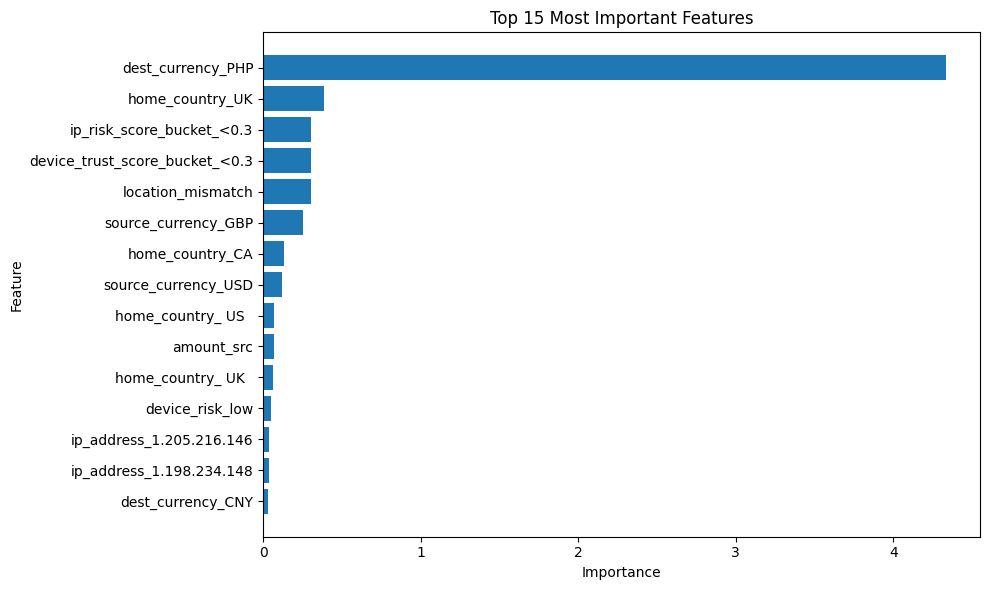

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_15 = feature_importance.head(15)
plt.barh(top_15['Feature'], top_15['Importance'])
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [186]:
REASON_CODE_MAP = {
    # RC01 – Destination / corridor
    "dest_currency": ("RC01", "Destination currency or corridor risk"),
    "corridor_risk": ("RC01", "Destination currency or corridor risk"),

    # RC02 – Source currency
    "source_currency": ("RC02", "Source currency risk"),

    # RC03 – Home country
    "home_country": ("RC03", "Home country risk profile"),
    "home_country_cleaned": ("RC03", "Home country risk profile"),

    # RC04 – Location inconsistency
    "location_mismatch": ("RC04", "Location or geographic inconsistency"),
    "ip_country": ("RC04", "Location or geographic inconsistency"),

    # RC05 – Device / IP trust
    "ip_address": ("RC05", "Device / IP trust profile"),
    "ip_risk": ("RC05", "Device / IP trust profile"),
    "ip_risk_score_bucket": ("RC05", "Device / IP trust profile"),
    "device_trust_score": ("RC05", "Device / IP trust profile"),
    "device_trust_score_bucket": ("RC05", "Device / IP trust profile"),
    "device_risk": ("RC05", "Device / IP trust profile"),
    "new_device": ("RC05", "Device / IP trust profile"),

    # RC06 – Account & behavior
    "amount_src": ("RC06", "Account tenure and transaction behavior"),
    "amount_usd": ("RC06", "Account tenure and transaction behavior"),
    "amount_bucket": ("RC06", "Account tenure and transaction behavior"),
    "amount_breakdown": ("RC06", "Account tenure and transaction behavior"),
    "fee": ("RC06", "Account tenure and transaction behavior"),
    "chargeback_history_count": ("RC06", "Account tenure and transaction behavior"),
    "risk_score_internal": ("RC06", "Account tenure and transaction behavior"),
    "account_age_bucket": ("RC06", "Account tenure and transaction behavior"),
    "account_age_breakdown": ("RC06", "Account tenure and transaction behavior"),
    "kyc_tier": ("RC06", "Account tenure and transaction behavior"),
    "channel": ("RC06", "Account tenure and transaction behavior"),
    "hour": ("RC06", "Account tenure and transaction behavior"),
    "day_of_week": ("RC06", "Account tenure and transaction behavior"),
    "month": ("RC06", "Account tenure and transaction behavior"),
    "is_weekend": ("RC06", "Account tenure and transaction behavior"),
    "night_hours": ("RC06", "Account tenure and transaction behavior"),
    "is_high_velocity_1h": ("RC06", "Account tenure and transaction behavior"),
    "is_high_velocity_24h": ("RC06", "Account tenure and transaction behavior"),
}


In [187]:
def split_feature(feature_name):
    """
    home_country_UK -> (home_country, UK)
    amount_src -> (amount_src, None)
    """
    parents = sorted(REASON_CODE_MAP.keys(), key=len, reverse=True)

    for parent in parents:
        if feature_name.startswith(parent):
            category = feature_name[len(parent):].lstrip("_")
            return parent, category if category else None



def impact_strength(shap_val):
    abs_val = abs(shap_val)
    if abs_val > 1.0:
        return "High"
    elif abs_val > 0.3:
        return "Medium"
    else:
        return "Low"


In [188]:
def explain_transaction(
    idx,
    model,
    threshold,
    shap_values,
    X_test,
    y_test_np,
    feature_names,
    top_k=5
):
    # --- basic prediction ---
    row = X_test[idx]
    shap_row = shap_values[idx]

    score = model.predict_proba(row.reshape(1, -1))[0, 1]
    prediction = "FRAUD" if score >= threshold else "LEGIT"
    true_label = "FRAUD" if y_test_np.iloc[idx] == 1 else "LEGIT"

    # --- build dataframe ---
    df = pd.DataFrame({
        "feature": feature_names,
        "value": row,
        "shap": shap_row
    })

    # split parent / category
    df[["parent", "category"]] = df["feature"].apply(
        lambda x: pd.Series(split_feature(x))
    )

    # keep only active categorical levels
    df = df[(df["category"].isna()) | (df["value"] != 0)]

    # aggregate SHAP by parent feature
    grouped = (
        df.groupby("parent", as_index=False)
          .agg({
              "shap": "sum",
              "category": lambda x: list(set(filter(None, x))),
          })
    )

    print( grouped.columns)

    grouped["abs_shap"] = grouped["shap"].abs()
    grouped = grouped.sort_values("abs_shap", ascending=False)

    risk = grouped[grouped["shap"] > 0].head(top_k)
    protective = grouped[grouped["shap"] < 0].head(top_k)

    # --- PRINT TEMPLATE ---
    print("TRANSACTION EXPLANATION")
    print("-" * 50)
    print(f"Transaction ID: Test Sample #{idx}")
    print(f"True Label: {true_label}")
    print(f"Model Decision: {prediction}")
    print(f"Model Confidence: {score:.2f}")

    print("\nPRIMARY REASON CODES (Why this transaction was flagged):")

    for i, (_, row) in enumerate(risk.iterrows(), start=1):
        rc, desc = REASON_CODE_MAP.get(
            row["parent"], ("RCXX", row["parent"])
        )
        category = ", ".join(row["category"]) if row["category"] else "N/A"
        strength = impact_strength(row["shap"])


        print(f"\n{i}. [{rc}] {desc}")
        print("   Direction: ↑ Increases fraud risk")
        print(f"   Active Signal: {row["parent"]} {category}")
        print(f"   Impact Strength: {strength}")

    if not protective.empty:
        print("\nPROTECTIVE SIGNALS (Factors reducing fraud risk):")

        for i, (_, row) in enumerate(protective.iterrows(), start=1):
            rc, desc = REASON_CODE_MAP.get(
                row["parent"], ("RCXX", row["parent"])
            )
            category = ", ".join(row["category"]) if row["category"] else "N/A"
            strength = impact_strength(row["shap"])

            print(f"\n{i}. [{rc}] {desc}")
            print("   Direction: ↓ Reduces fraud risk")
            print(f"   Active Signal: {row["parent"]} {category}")
            print(f"   Impact Strength: {strength}")


In [190]:
shap_sample_size = fraud_shap.shape[0]

fraud_indices_shap = np.where(y_test[:shap_sample_size] == 1)[0]

random_fraud_idx = random.choice(fraud_indices_shap)

print(f"Random fraud test samle index: {random_fraud_idx}")

original_row_idx = test_df.index[random_fraud_idx]
print(f"\nOriginal transaction data")
print(test_df.loc[original_row_idx, [
    'account_age_breakdown', 'channel', 'kyc_tier', 'risk_score_internal', 'is_fraud',
    'new_device', 'dest_currency'
]])

print('\n' + '-' * 50 + '\n')

threshold = 0.7

print(explain_transaction(
    random_fraud_idx,
    smote_xgb_model,
    threshold,
    fraud_shap,
    X_test_preprocessed[:shap_sample_size],
    y_test[:shap_sample_size],
    all_feature_names
))


Random fraud test samle index: 0

Original transaction data
account_age_breakdown    very new
channel                       web
kyc_tier                 standard
risk_score_internal         0.731
is_fraud                        1
new_device                   True
dest_currency                 INR
Name: 8605, dtype: object

--------------------------------------------------

Index(['parent', 'shap', 'category'], dtype='object')
TRANSACTION EXPLANATION
--------------------------------------------------
Transaction ID: Test Sample #0
True Label: FRAUD
Model Decision: FRAUD
Model Confidence: 1.00

PRIMARY REASON CODES (Why this transaction was flagged):

1. [RC01] Destination currency or corridor risk
   Direction: ↑ Increases fraud risk
   Active Signal: dest_currency GBP, PHP, EUR, MXN, CNY, NGN, INR
   Impact Strength: High

2. [RC03] Home country risk profile
   Direction: ↑ Increases fraud risk
   Active Signal: home_country CA, UK, US,  UK  ,  US  
   Impact Strength: Medium

3. [RC0

# Save Model and Explainer

In [212]:
import joblib

joblib.dump(smote_xgb_model, "fraud_model_xgb.joblib")


['fraud_model_xgb.joblib']

In [213]:
explainer_xgb = shap.TreeExplainer(smote_xgb_model)

joblib.dump(explainer_xgb, "shap_explainer_xgb.joblib")

['shap_explainer_xgb.joblib']

In [214]:
np.save("shap_values_xgb.npy", shap_values_xgb)

In [216]:
import json

with open("feature_names.json", "w") as f:
    json.dump(all_feature_names, f)